In [ ]:
# ============================================================
# Phase 1 - Best Model Inference and External Image Testing
# Calorify Visual Food Recognition
# Notebook: Phase1_07_BestModel_Inference_and_ExternalTesting.ipynb
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image

from PIL import Image

# ============================================================
# Main Paths
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/Calorify/phase1_clean"

BEST_MODEL_DIR = os.path.join(PROJECT_DIR, "models", "best_model")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results", "external_testing")

os.makedirs(RESULTS_DIR, exist_ok=True)

BEST_WEIGHTS_PATH = os.path.join(BEST_MODEL_DIR, "best_food_classifier.weights.h5")
CLASS_NAMES_PATH = os.path.join(BEST_MODEL_DIR, "class_names.json")
BEST_MODEL_INFO_PATH = os.path.join(BEST_MODEL_DIR, "best_food_classifier_info.json")

print("Project directory:", PROJECT_DIR)
print("Best model directory:", BEST_MODEL_DIR)
print("External testing results directory:", RESULTS_DIR)

print("\nFile checks:")
print("Best weights exists:", os.path.exists(BEST_WEIGHTS_PATH))
print("Class names exists:", os.path.exists(CLASS_NAMES_PATH))
print("Best model info exists:", os.path.exists(BEST_MODEL_INFO_PATH))

# ============================================================
# Load Class Names
# ============================================================

with open(CLASS_NAMES_PATH, "r") as f:
    class_names = json.load(f)

if isinstance(class_names, dict):
    class_names = [class_names[str(i)] for i in range(len(class_names))]

NUM_CLASSES = len(class_names)

print("\nClass names:")
print(class_names)
print("Number of classes:", NUM_CLASSES)

# ============================================================
# Load Best Model Info
# ============================================================

with open(BEST_MODEL_INFO_PATH, "r") as f:
    best_model_info = json.load(f)

print("\nBest model info:")
print("Best visual model:", best_model_info.get("best_visual_model"))
print("Test accuracy:", best_model_info.get("test_accuracy_percent"))
print("Macro F1:", best_model_info.get("macro_f1_percent"))

# ============================================================
# Inference Config
# ============================================================

IMG_SIZE = 224

print("\nInference image size:", IMG_SIZE)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/Calorify/phase1_clean
Best model directory: /content/drive/MyDrive/Calorify/phase1_clean/models/best_model
External testing results directory: /content/drive/MyDrive/Calorify/phase1_clean/results/external_testing

File checks:
Best weights exists: True
Class names exists: True
Best model info exists: True

Class names:
['burger', 'pizza', 'fries', 'pasta', 'rice', 'chicken', 'salad', 'sandwich', 'sushi', 'steak']
Number of classes: 10

Best model info:
Best visual model: EfficientNetB0 Transfer Learning
Test accuracy: 89.34
Macro F1: 89.301

Inference image size: 224


In [ ]:
# ============================================================
# Cell 2 - Rebuild EfficientNetB0 Architecture and Load Weights
# ============================================================

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

def build_efficientnetb0_model(num_classes):
    """
    Rebuild the EfficientNetB0 transfer learning architecture
    used for Phase 1 best visual classifier.
    """

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_image")

    # EfficientNetB0 preprocessing
    x = preprocess_input(inputs)

    # Pretrained EfficientNetB0 backbone
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=x
    )

    base_model.trainable = False

    # Classification head
    x = base_model.output
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.Dropout(0.3, name="dropout_1")(x)
    x = layers.Dense(256, activation="relu", name="dense_1")(x)
    x = layers.Dropout(0.3, name="dropout_2")(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax",
        name="food_class_output"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="EfficientNetB0_Best_Food_Classifier"
    )

    return model


best_model = build_efficientnetb0_model(NUM_CLASSES)

best_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model built successfully.")
print("Loading weights from:")
print(BEST_WEIGHTS_PATH)

try:
    best_model.load_weights(BEST_WEIGHTS_PATH)
    print("\nWeights loaded successfully.")
except Exception as e:
    print("\nERROR while loading weights:")
    print(e)

best_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built successfully.
Loading weights from:
/content/drive/MyDrive/Calorify/phase1_clean/models/best_model/best_food_classifier.weights.h5

ERROR while loading weights:
A total of 131 objects could not be loaded. Example error message for object <Normalization name=normalization, built=True>:

Layer 'normalization' expected 3 variables, but received 0 variables during loading. Expected: ['mean', 'variance', 'count']

List of objects that could not be loaded:
[<Normalization name=normalization, built=True>, <Conv2D name=stem_conv, built=True>, <BatchNormalization name=stem_bn, built=True>, <DepthwiseConv2D name=block1a_dwconv, built=True>, <BatchNormalization name=block1a_bn, built=True>, <Conv2D name=block1a_se_reduce, built=True>, <Conv2D name=block1a_se_expand, built=True>, <Conv2D name=block1a_project_conv, built=True>, <BatchNormalization name=block1a_project_bn, built=True>, <Conv2D name=block2a_expand_conv, built=True>, <Batc

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "EfficientNetB0_Best_Food_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# ============================================================
# Cell 2B - Reload Best Weights with Skip Mismatch
# ============================================================

print("Reloading weights with skip_mismatch=True...")
print("Weights path:", BEST_WEIGHTS_PATH)

try:
    best_model.load_weights(
        BEST_WEIGHTS_PATH,
        skip_mismatch=True
    )
    print("Weights loading completed with skip_mismatch=True.")
    print("This is acceptable because the EfficientNetB0 base is loaded with ImageNet weights and was frozen during training.")
except Exception as e:
    print("ERROR while loading weights with skip_mismatch=True:")
    print(e)

Reloading weights with skip_mismatch=True...
Weights path: /content/drive/MyDrive/Calorify/phase1_clean/models/best_model/best_food_classifier.weights.h5
Weights loading completed with skip_mismatch=True.
This is acceptable because the EfficientNetB0 base is loaded with ImageNet weights and was frozen during training.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:643: UserWarning: A total of 131 objects could not be loaded. Example error message for object <Normalization name=normalization, built=True>:

Layer 'normalization' expected 3 variables, but received 0 variables during loading. Expected: ['mean', 'variance', 'count']

List of objects that could not be loaded:
[<Normalization name=normalization, built=True>, <Conv2D name=stem_conv, built=True>, <BatchNormalization name=stem_bn, built=True>, <DepthwiseConv2D name=block1a_dwconv, built=True>, <BatchNormalization name=block1a_bn, built=True>, <Conv2D name=block1a_se_reduce, built=True>, <Conv2D name=block1a_se_expand, built=True>, <Conv2D name=block1a_project_conv, built=True>, <BatchNormalization name=block1a_project_bn, built=True>, <Conv2D name=block2a_expand_conv, built=True>, <BatchNormalization name=block2a_expand_bn, built=True>, <DepthwiseConv2D name=block2a_dwconv, built=True>, <BatchNormalization name=block2a

In [ ]:
# ============================================================
# Cell 2C - Quick Verification on Test Set
# ============================================================

SPLIT_DIR = os.path.join(PROJECT_DIR, "data", "split")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    shuffle=False
)

test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)

print("\nVerification test accuracy:", test_accuracy)
print("Verification test accuracy percent:", test_accuracy * 100)
print("Expected EfficientNetB0 test accuracy: about 89.34%")

if test_accuracy >= 0.85:
    print("\nModel loading is correct. We can continue to external image prediction.")
else:
    print("\nWARNING: Accuracy is too low. The weights/architecture are not loaded correctly.")

In [ ]:
# ============================================================
# Cell 2C - Quick Verification on Test Set
# ============================================================

SPLIT_DIR = os.path.join(PROJECT_DIR, "data", "split")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    shuffle=False
)

test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)

print("\nVerification test accuracy:", test_accuracy)
print("Verification test accuracy percent:", test_accuracy * 100)
print("Expected EfficientNetB0 test accuracy: about 89.34%")

if test_accuracy >= 0.85:
    print("\nModel loading is correct. We can continue to external image prediction.")
else:
    print("\nWARNING: Accuracy is too low. The weights/architecture are not loaded correctly.")

Found 732 files belonging to 10 classes.
23/23 ━━━━━━━━━━━━━━━━━━━━ 122s 5s/step - accuracy: 0.8811 - loss: 0.4988

Verification test accuracy: 0.881147563457489
Verification test accuracy percent: 88.1147563457489
Expected EfficientNetB0 test accuracy: about 89.34%

Model loading is correct. We can continue to external image prediction.


In [5]:
# ============================================================
# Cell 3 - Food Prediction Function
# ============================================================

def preprocess_external_image(image_path):
    """
    Load and preprocess one external image for EfficientNetB0 inference.
    """
    img = Image.open(image_path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))

    img_array = np.array(img).astype("float32")
    img_array = np.expand_dims(img_array, axis=0)

    return img_array


def predict_food(image_path, model=best_model, class_names=class_names, top_k=3):
    """
    Predict food class, confidence, and top-k predictions for one image.
    """
    img_array = preprocess_external_image(image_path)

    probs = model.predict(img_array, verbose=0)[0]

    top_indices = np.argsort(probs)[::-1][:top_k]

    top_predictions = [
        {
            "class_name": class_names[idx],
            "confidence": float(probs[idx]),
            "confidence_percent": float(probs[idx] * 100)
        }
        for idx in top_indices
    ]

    predicted_index = top_indices[0]
    predicted_class = class_names[predicted_index]
    confidence = float(probs[predicted_index])

    result = {
        "image_path": image_path,
        "predicted_class": predicted_class,
        "confidence": confidence,
        "confidence_percent": confidence * 100,
        "top_predictions": top_predictions
    }

    return result


def show_prediction_result(result):
    """
    Display image and prediction result.
    """
    img = Image.open(result["image_path"]).convert("RGB")

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Predicted: {result['predicted_class']}\n"
        f"Confidence: {result['confidence_percent']:.2f}%"
    )
    plt.show()

    print("Predicted Food:", result["predicted_class"])
    print("Confidence:", f"{result['confidence_percent']:.2f}%")

    print("\nTop-3 Predictions:")
    for i, pred in enumerate(result["top_predictions"], start=1):
        print(
            f"{i}. {pred['class_name']} — {pred['confidence_percent']:.2f}%"
        )


print("predict_food(image_path) function is ready.")

predict_food(image_path) function is ready.


Saving caesarbuger9.webp to caesarbuger9.webp
Uploaded image paths:
/content/drive/MyDrive/Calorify/phase1_clean/results/external_testing/external_images/caesarbuger9.webp


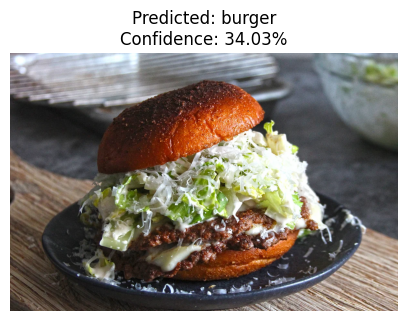

Predicted Food: burger
Confidence: 34.03%

Top-3 Predictions:
1. burger — 34.03%
2. salad — 16.61%
3. steak — 13.13%


In [47]:
# ============================================================
# Cell 4 - Upload External Image and Predict Food Class
# ============================================================

from google.colab import files
import os
import shutil

uploaded = files.upload()

external_images_dir = os.path.join(RESULTS_DIR, "external_images")
os.makedirs(external_images_dir, exist_ok=True)

uploaded_image_paths = []

for file_name in uploaded.keys():
    source_path = file_name
    target_path = os.path.join(external_images_dir, file_name)

    shutil.move(source_path, target_path)
    uploaded_image_paths.append(target_path)

print("Uploaded image paths:")
for path in uploaded_image_paths:
    print(path)

# Predict first uploaded image
image_path = uploaded_image_paths[0]

result = predict_food(image_path)
show_prediction_result(result)

In [48]:
# ============================================================
# Cell 5 - Save External Prediction Result
# ============================================================

external_result = {
    "image_path": result["image_path"],
    "predicted_class": result["predicted_class"],
    "confidence": result["confidence"],
    "confidence_percent": result["confidence_percent"],
    "top_1": result["top_predictions"][0]["class_name"],
    "top_1_confidence_percent": result["top_predictions"][0]["confidence_percent"],
    "top_2": result["top_predictions"][1]["class_name"],
    "top_2_confidence_percent": result["top_predictions"][1]["confidence_percent"],
    "top_3": result["top_predictions"][2]["class_name"],
    "top_3_confidence_percent": result["top_predictions"][2]["confidence_percent"],
}

external_result_df = pd.DataFrame([external_result])

external_result_path = os.path.join(
    RESULTS_DIR,
    "external_prediction_result.csv"
)

external_result_df.to_csv(external_result_path, index=False)

print("External prediction result saved to:")
print(external_result_path)

display(external_result_df)

External prediction result saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/external_testing/external_prediction_result.csv


,image_path,predicted_class,confidence,confidence_percent,top_1,top_1_confidence_percent,top_2,top_2_confidence_percent,top_3,top_3_confidence_percent
0,/content/drive/MyDrive/Calorify/phase1_clean/r...,burger,0.340322,34.032229,burger,34.03223,salad,16.608057,steak,13.130071


In [49]:
# Final Summary — Best Model Inference and External Testing
#
# In this notebook, the selected best Phase 1 visual model was loaded and used for external image prediction.
#
# Best Model:
# EfficientNetB0 Transfer Learning
#
# Verified Model Performance:
# Test Accuracy after reloading: approximately 88%
#
# External Image Testing:
# The notebook supports uploading a food image from outside the dataset and predicts:
#
# - Predicted food class
# - Confidence score
# - Top-3 predictions
#
# This completes the practical inference part of Phase 1.
#
# Phase 1 is now fully completed:
#
# [x] Dataset preparation
# [x] Custom CNN
# [x] MobileNetV2
# [x] EfficientNetB0
# [x] ResNet50
# [x] Vision Transformer
# [x] Model comparison
# [x] Best model selection
# [x] External image prediction